In [ ]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms
import csv


Found 468 complete flatness runs matching volume and geometry filters
Radius bounds: (0.0, 100.0) mm
Height bounds: (0.0, 100.0) mm
Thickness bounds: (0.0, 100.0) mm
include_lids = True
Using /Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test/0p5to1_r5mmh1cm_bathed_1e9/0

L = V/A_proj:       0.212843 cm
L flux-weighted:   0.117948 cm
L_flux / L_geom:   0.554157



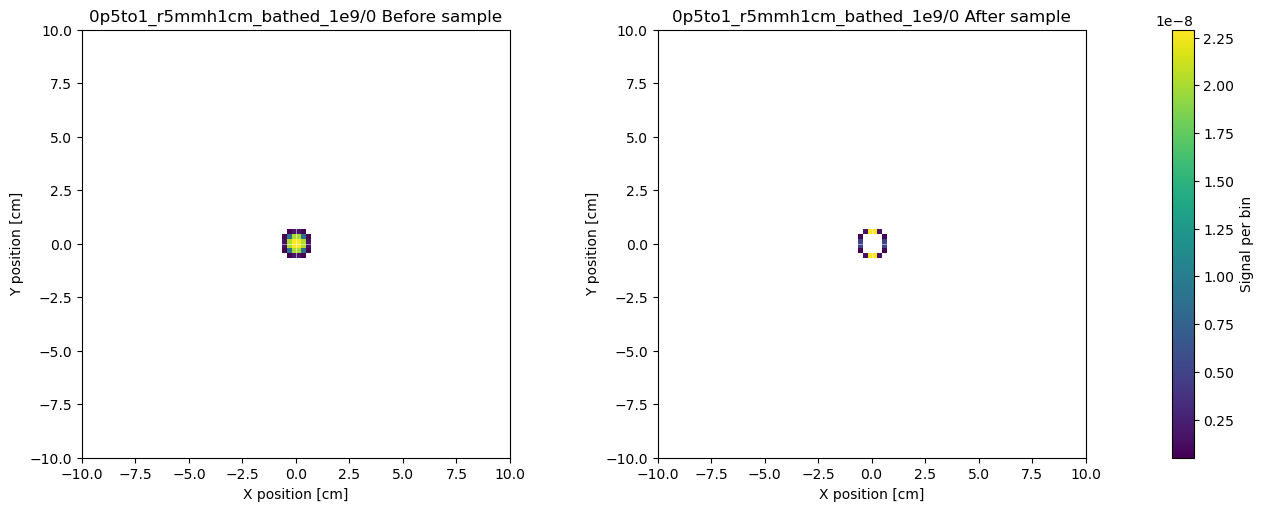

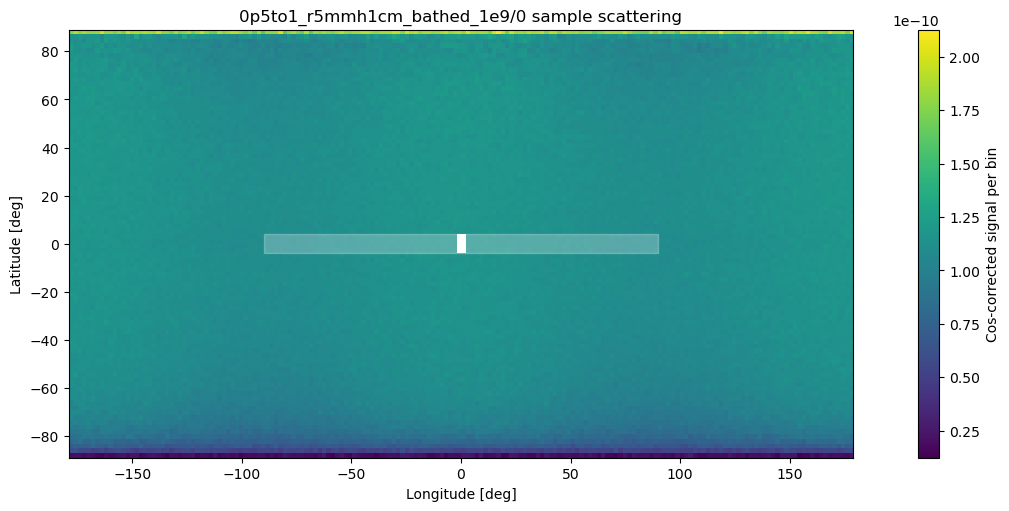

Selected run diagnostics
------------------------
Flux before sample, total monitor sum: 2.94498e-05
Flux after sample, total monitor sum:  1.2006e-07
Before - after:                     2.93298e-05
(Before - after) / before:           0.995923

Beam area before sample:             1.58025 cm^2
Cylinder radius:                     5 mm
Cylinder height:                     10 mm
Cylinder wall thickness:             0.5 mm
Side-wall volume:                    0.149226 cm^3
Closed-shell volume:                 0.212843 cm^3
Volume used:                         0.212843 cm^3
Projected sample area:               1 cm^2

L = V/A_proj:                        0.212843 cm
L flux-weighted:                     0.117948 cm
P_scatt geometric:                   0.072304
P_scatt flux-weighted:               0.0414194

Expected scattered source strength:  1.17799e-06
Detector window solid angle:         0.214407 sr
Expected summed window intensity:    2.00988e-08
Observed summed window intensity:    1

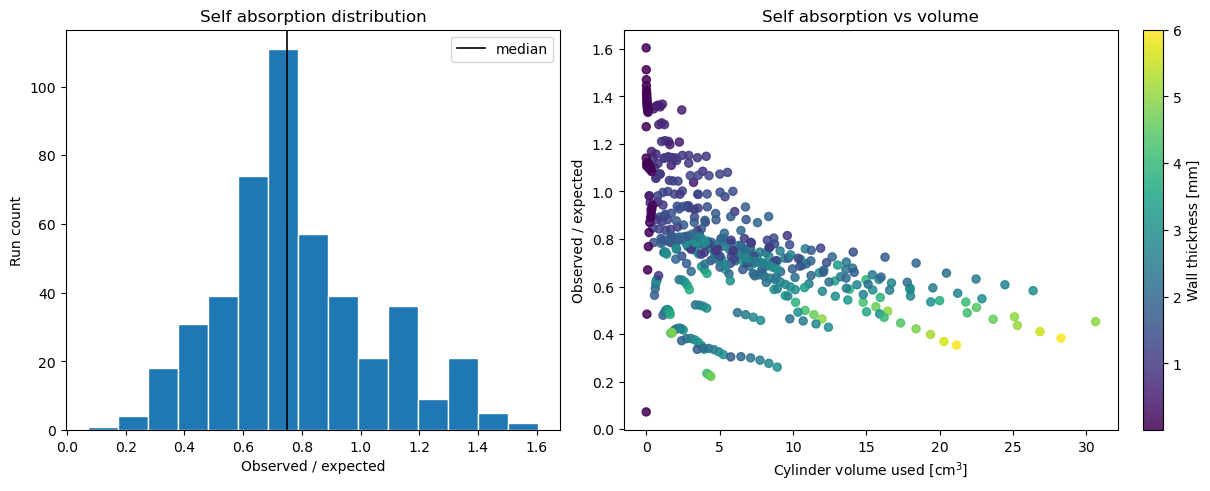

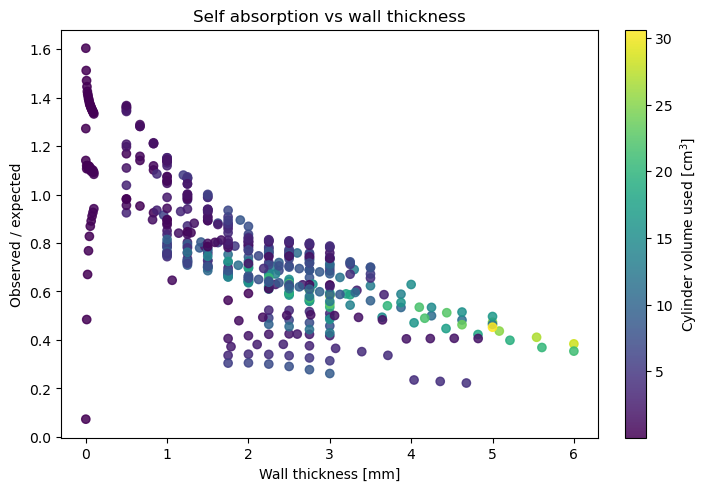

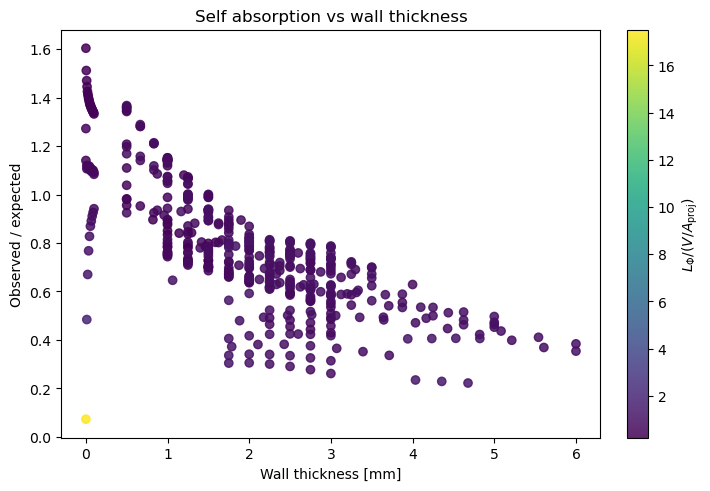

In [46]:
# ============================================================
# Self absorption analysis
# Closed-shell version: side wall + top/bottom lids
# ============================================================

from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================

flatness_root = Path('geometry_optimization/cylinder_instrument/flatness_test')
if not flatness_root.exists():
    flatness_root = Path('/Users/christian/Documents/Study/bachelor_project') / flatness_root

Sigma_inc_cm_inv = 0.367
Sigma_abs_cm_inv = Sigma_inc_cm_inv
Sigma_coh_cm_inv = 1.786e-3

Sigma_s_cm_inv = Sigma_inc_cm_inv + Sigma_coh_cm_inv
Sigma_total_cm_inv = Sigma_inc_cm_inv + Sigma_coh_cm_inv + Sigma_abs_cm_inv

# If True: P_scatt = Sigma_inc * L
# If False: P_scatt = (Sigma_inc / Sigma_total) * (1 - exp(-Sigma_total * L))
use_linear_probability = False

# This should match the McStas sample geometry.
# True  = closed hollow cylinder: side wall + lids
# False = open hollow cylinder: side wall only
include_lids = True

required_monitor_files = ('cylinder_scattered.dat', 'before.dat', 'after.dat')

nominal_detector_center_deg = 0.0
detector_window_width_deg = 180.0

equator_band_halfwidth_local = 2.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0

filtering_enabled = False
if filtering_enabled:
    minimum_sample_volume_cm3 = 1.0
    radius_bounds_mm = (4.0, 13.0)
    height_bounds_mm = (7.0, 61.0)
    thickness_bounds_mm = (0.4, 3.5)
else:
    minimum_sample_volume_cm3 = 0.0
    radius_bounds_mm = (0.0, 100.0)
    height_bounds_mm = (0.0, 100.0)
    thickness_bounds_mm = (0.0, 100.0)

selected_scan_name = None
selected_run_index = None

# ============================================================
# Basic run handling
# ============================================================

def missing_monitor_files(run_dir):
    run_dir = Path(run_dir)
    return [name for name in required_monitor_files if not (run_dir / name).is_file()]


def is_complete_flatness_run(run_dir):
    return not missing_monitor_files(run_dir)


def validate_flatness_run(run_dir):
    run_dir = Path(run_dir)
    missing = missing_monitor_files(run_dir)
    if missing:
        raise FileNotFoundError(f'{run_dir} is missing required file(s): {missing}')
    return run_dir


def value_in_bounds(value, bounds):
    lower, upper = bounds
    return lower <= value <= upper


def numeric_sort_key(path):
    path = Path(path)
    try:
        run_number = int(path.name)
    except ValueError:
        run_number = path.name
    return (path.parent.name, run_number, str(path))


def find_complete_flatness_runs(root):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f'Flatness test directory does not exist: {root}')

    candidate_dirs = sorted({p.parent for p in root.rglob('cylinder_scattered.dat')})
    complete = [run_dir for run_dir in candidate_dirs if is_complete_flatness_run(run_dir)]

    filtered = []
    for run_dir in complete:
        try:
            if (
                sample_volume_cm3(run_dir) >= minimum_sample_volume_cm3
                and geometry_in_bounds(run_dir)
            ):
                filtered.append(run_dir)
        except Exception:
            pass

    return sorted(filtered, key=numeric_sort_key)


def select_flatness_run(runs, scan_name=None, run_index=None):
    selected = list(runs)

    if scan_name is not None:
        selected = [run_dir for run_dir in selected if run_dir.parent.name == scan_name]

    if run_index is not None:
        selected = [run_dir for run_dir in selected if run_dir.name == str(run_index)]

    if not selected:
        raise ValueError(
            f'No complete flatness run found for scan_name={scan_name!r}, '
            f'run_index={run_index!r}'
        )

    return selected[0]


# ============================================================
# Metadata and geometry
# ============================================================

def parse_mccode_params(metadata_file):
    metadata_file = Path(metadata_file)
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')

    with metadata_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue

            key = match.group(1).strip()
            raw_value = match.group(2).strip()

            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    return params


def geometry_metadata_file(run_dir):
    run_dir = Path(run_dir)

    for name in ('mccode.sim', 'cylinder_scattered.dat', 'before.dat', 'after.dat'):
        candidate = run_dir / name
        if candidate.is_file():
            return candidate

    raise FileNotFoundError(f'No McCode metadata file found in {run_dir}')


def parse_mccode_sim(sim_file):
    params = parse_mccode_params(sim_file)

    required = ['cylinder_radius', 'cylinder_height', 'thickness']
    missing = [key for key in required if key not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    return {
        'outer_radius_mm': params['cylinder_radius'] * 1000.0,
        'outer_height_mm': params['cylinder_height'] * 1000.0,
        'wall_thickness_mm': params['thickness'] * 1000.0,
    }


def geometry_in_bounds(run_dir):
    try:
        geometry = parse_mccode_sim(geometry_metadata_file(run_dir))
    except (FileNotFoundError, ValueError):
        return False

    return (
        value_in_bounds(geometry['outer_radius_mm'], radius_bounds_mm)
        and value_in_bounds(geometry['outer_height_mm'], height_bounds_mm)
        and value_in_bounds(geometry['wall_thickness_mm'], thickness_bounds_mm)
    )


# ============================================================
# Volume and projected area
# ============================================================

def side_wall_volume_cm3(run_dir):
    validate_flatness_run(run_dir)

    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0
    t = geometry['wall_thickness_mm'] / 10.0

    r = R - t
    if r <= 0:
        return np.pi * R**2 * H

    return np.pi * (R**2 - r**2) * H


def closed_shell_volume_cm3(run_dir):
    validate_flatness_run(run_dir)

    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0
    t = geometry['wall_thickness_mm'] / 10.0

    r = R - t
    h_inner = H - 2.0 * t

    if r <= 0 or h_inner <= 0:
        return np.pi * R**2 * H

    return np.pi * R**2 * H - np.pi * r**2 * h_inner


def sample_volume_cm3(run_dir):
    if include_lids:
        return closed_shell_volume_cm3(run_dir)
    return side_wall_volume_cm3(run_dir)


def projected_area_cm2(run_dir):
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0

    return 2.0 * R * H


def mean_incoming_path_length_cm(run_dir):
    return sample_volume_cm3(run_dir) / projected_area_cm2(run_dir)


# ============================================================
# Load monitor files
# ============================================================

def load_mccode_2d(path):
    path = Path(path)

    meta = {}
    nrows = None
    data_rows = []
    in_data = False

    with path.open() as f:
        for line in f:
            if line.startswith('# type: array_2d'):
                dims = line.split('array_2d(', 1)[1].split(')', 1)[0]
                nrows = int(dims.split(',')[1].strip())

            elif line.startswith('# xylimits:'):
                meta['extent'] = [float(v) for v in line.split(':', 1)[1].split()]

            elif line.startswith('# component:'):
                meta['component'] = line.split(':', 1)[1].strip()

            elif line.startswith('# Data'):
                in_data = True

            elif in_data and line.startswith('#'):
                break

            elif in_data and line.strip():
                data_rows.append([float(v) for v in line.split()])
                if nrows is not None and len(data_rows) == nrows:
                    break

    if nrows is None:
        raise ValueError(f'Could not find array_2d dimensions in {path}')

    if len(data_rows) != nrows:
        raise ValueError(f'Expected {nrows} rows from {path}, got {len(data_rows)}')

    data = np.array(data_rows, dtype=float)

    return data, meta


def before_after_intensity(run_dir):
    run_dir = validate_flatness_run(run_dir)

    before_data, _ = load_mccode_2d(run_dir / 'before.dat')
    after_data, _ = load_mccode_2d(run_dir / 'after.dat')

    return np.nansum(before_data), np.nansum(after_data)


def load_scattered_monitor(run_dir):
    run_dir = validate_flatness_run(run_dir)

    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    for item in loaded:
        name = str(getattr(item, 'name', '') or '')
        component = str(getattr(item, 'component_name', '') or '')
        filename = str(getattr(getattr(item, 'metadata', None), 'filename', '') or '')

        if (
            'cylinder_scattered' in name
            or 'cylinder_scattered' in filename
            or 'mon_4pi' in component
        ):
            return item

    return loaded[2] if len(loaded) >= 3 else loaded[-1]


# ============================================================
# Path length through sample
# ============================================================

def side_wall_chord_length_cm(x_cm, geometry):
    """
    Open hollow cylinder side-wall path length.

    Beam direction is assumed along z.
    Cylinder axis is vertical along y.
    x_cm is the horizontal transverse coordinate.
    """
    R = geometry['outer_radius_mm'] / 10.0
    t = geometry['wall_thickness_mm'] / 10.0
    r = R - t

    x = np.asarray(x_cm, dtype=float)
    ax = np.abs(x)

    L = np.zeros_like(ax, dtype=float)

    outer = ax <= R
    inner = ax < r

    L[outer] = 2.0 * np.sqrt(np.maximum(R**2 - ax[outer]**2, 0.0))

    if r > 0:
        L[inner] -= 2.0 * np.sqrt(np.maximum(r**2 - ax[inner]**2, 0.0))

    return L


def shell_chord_length_cm(x_cm, y_cm, geometry):
    """
    Closed hollow cylinder path length:
    outer cylinder minus inner cavity.

    Beam direction is assumed along z.
    Cylinder axis is vertical along y.

    x_cm and y_cm are transverse coordinates.
    """
    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0
    t = geometry['wall_thickness_mm'] / 10.0

    r = R - t
    inner_half_height = H / 2.0 - t

    x = np.asarray(x_cm, dtype=float)
    y = np.asarray(y_cm, dtype=float)

    ax, ay = np.broadcast_arrays(np.abs(x), np.abs(y))

    L = np.zeros_like(ax, dtype=float)

    outer = (ax <= R) & (ay <= H / 2.0)

    L[outer] = 2.0 * np.sqrt(np.maximum(R**2 - ax[outer]**2, 0.0))

    if r > 0 and inner_half_height > 0:
        inner = (ax < r) & (ay <= inner_half_height)
        L[inner] -= 2.0 * np.sqrt(np.maximum(r**2 - ax[inner]**2, 0.0))

    return L


def sample_chord_length_cm(X_cm, Y_cm, geometry):
    if include_lids:
        return shell_chord_length_cm(X_cm, Y_cm, geometry)
    return side_wall_chord_length_cm(X_cm, geometry)


def projected_sample_pixels(run_dir):
    """
    Returns I_before, X, Y for pixels inside projected sample area.
    """
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    before_data, before_meta = load_mccode_2d(Path(run_dir) / 'before.dat')
    extent = before_meta.get('extent')

    if extent is None:
        raise ValueError(f'before.dat is missing xylimits/extent for {run_dir}')

    x_min, x_max, y_min, y_max = extent
    n_y, n_x = before_data.shape

    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0

    x_mask = (x_centers >= -R) & (x_centers <= R)
    y_mask = (y_centers >= -0.5 * H) & (y_centers <= 0.5 * H)

    I = np.asarray(before_data[np.ix_(y_mask, x_mask)], dtype=float)

    X, Y = np.meshgrid(x_centers[x_mask], y_centers[y_mask])

    return I, X, Y, geometry


def flux_weighted_mean_path_length_cm(run_dir):
    I, X, Y, geometry = projected_sample_pixels(run_dir)

    Lxy = sample_chord_length_cm(X, Y, geometry)

    denominator = np.nansum(I)
    if denominator <= 0:
        return np.nan

    return float(np.nansum(I * Lxy) / denominator)


def compare_path_lengths(run_dir):
    L_geom = mean_incoming_path_length_cm(run_dir)
    L_flux = flux_weighted_mean_path_length_cm(run_dir)

    print(f'L = V/A_proj:       {L_geom:.6g} cm')
    print(f'L flux-weighted:   {L_flux:.6g} cm')
    print(f'L_flux / L_geom:   {L_flux / L_geom:.6g}')


# ============================================================
# Scattering probability and expected intensity
# ============================================================

def scattering_probability_from_path_length(L_cm):
    """
    Probability that the first interaction is an incoherent scattering event.

    Linear:
        P = Sigma_inc * L

    Nonlinear competing-process estimate:
        P = (Sigma_inc / Sigma_total) * (1 - exp(-Sigma_total * L))
    """
    L_cm = np.asarray(L_cm, dtype=float)

    if use_linear_probability:
        return Sigma_inc_cm_inv * L_cm

    if Sigma_total_cm_inv <= 0:
        return np.zeros_like(L_cm, dtype=float)

    return (
        Sigma_inc_cm_inv / Sigma_total_cm_inv
        * (1.0 - np.exp(-Sigma_total_cm_inv * L_cm))
    )


def naive_scattering_probability(run_dir):
    """
    Geometric estimate using L = V / A_proj.
    Kept for comparison.
    """
    L_mean = mean_incoming_path_length_cm(run_dir)
    return float(scattering_probability_from_path_length(L_mean))


def flux_weighted_scattering_probability(run_dir):
    """
    Flux-weighted average scattering probability.

    Returns

        sum I_before(x,y) P_scatt(x,y) / sum I_before(x,y)

    over the projected sample area.
    """
    I, X, Y, geometry = projected_sample_pixels(run_dir)

    Lxy = sample_chord_length_cm(X, Y, geometry)
    Pxy = scattering_probability_from_path_length(Lxy)

    numerator = np.nansum(I * Pxy)
    denominator = np.nansum(I)

    if denominator <= 0:
        return np.nan

    return float(numerator / denominator)


def expected_scattered_source_strength(run_dir):
    """
    Expected total single-scattered source strength.

    Computes

        sum_pixels I_before(x,y) * P_scatt(x,y)

    over the projected sample area.
    """
    I, X, Y, geometry = projected_sample_pixels(run_dir)

    Lxy = sample_chord_length_cm(X, Y, geometry)
    Pxy = scattering_probability_from_path_length(Lxy)

    return float(np.nansum(I * Pxy))


# ============================================================
# Spherical monitor window and solid angle
# ============================================================

def angular_window_mask(angles_deg, center_deg, width_deg):
    half_width = width_deg / 2.0
    wrapped_delta = (angles_deg - center_deg + 180.0) % 360.0 - 180.0
    return np.abs(wrapped_delta) <= half_width


def detector_window_observed_sum_and_solid_angle(
    run_dir,
    center_deg=nominal_detector_center_deg,
    width_deg=detector_window_width_deg,
):
    """
    Returns:
        observed_sum: raw summed intensity in selected detector window
        omega_window: solid angle of the same selected pixels

    The observed sum uses raw spherical monitor intensities.
    The solid angle calculation already accounts for cos(latitude).
    """
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata

    H = np.array(sphere_mon.Intensity, copy=True)

    if hasattr(meta, 'dimension') and H.shape == (meta.dimension[0], meta.dimension[1]):
        H = H.T

    xmin, xmax, ymin, ymax = meta.limits

    n_lat, n_lon = H.shape

    lon_edges = np.linspace(xmin, xmax, n_lon + 1)
    lat_edges = np.linspace(ymin, ymax, n_lat + 1)

    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    Lon, Lat = np.meshgrid(lon_centers, lat_centers)

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        & (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    lon_mask = angular_window_mask(lon_centers, center_deg, width_deg)
    lat_mask = np.abs(lat_centers) <= equator_band_halfwidth_local

    window_mask = np.outer(lat_mask, lon_mask)

    valid_mask = (
        window_mask
        & ~beam_center_mask
        & np.isfinite(H)
        & (H > 0)
    )

    observed_sum = float(np.nansum(H[valid_mask]))

    omega = 0.0
    for i in range(n_lat):
        if not lat_mask[i]:
            continue

        lat1 = np.deg2rad(lat_edges[i])
        lat2 = np.deg2rad(lat_edges[i + 1])

        for j in range(n_lon):
            if not valid_mask[i, j]:
                continue

            lon1 = np.deg2rad(lon_edges[j])
            lon2 = np.deg2rad(lon_edges[j + 1])
            dphi = lon2 - lon1

            domega = dphi * (np.sin(lat2) - np.sin(lat1))
            omega += domega

    return observed_sum, float(omega)


def expected_intensity_in_detector_window(run_dir):
    """
    Expected intensity in the exact same detector window as the observed sum.
    """
    _, omega_window = detector_window_observed_sum_and_solid_angle(run_dir)

    return (
        expected_scattered_source_strength(run_dir)
        * omega_window
        / (4.0 * np.pi)
    )


def self_absorption(run_dir):
    observed_sum, _ = detector_window_observed_sum_and_solid_angle(run_dir)
    expected_sum = expected_intensity_in_detector_window(run_dir)

    return observed_sum / expected_sum


# ============================================================
# Corrected heatmap for visualization only
# ============================================================

def get_corrected_heatmap_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata

    H = np.array(sphere_mon.Intensity, copy=True)
    H_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and H.shape == (meta.dimension[0], meta.dimension[1]):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    Lon, Lat = np.meshgrid(lon_centers, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        & (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    H_corr = np.where(~beam_center_mask, H_corr, np.nan)
    H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

    return lon_centers, lat_centers, H_corr, H_err_corr


# ============================================================
# Row computation
# ============================================================

def self_absorption_result_row(run_dir):
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))
    before_intensity, after_intensity = before_after_intensity(run_dir)

    observed_sum, omega_window = detector_window_observed_sum_and_solid_angle(run_dir)
    expected_source = expected_scattered_source_strength(run_dir)
    expected_sum = expected_source * omega_window / (4.0 * np.pi)

    absorption = observed_sum / expected_sum

    L_geom = mean_incoming_path_length_cm(run_dir)
    L_flux = flux_weighted_mean_path_length_cm(run_dir)

    return {
        'run_dir': Path(run_dir),
        'scan': Path(run_dir).parent.name,
        'run': Path(run_dir).name,

        'radius_mm': geometry['outer_radius_mm'],
        'height_mm': geometry['outer_height_mm'],
        'thickness_mm': geometry['wall_thickness_mm'],
        'volume_cm3': sample_volume_cm3(run_dir),
        'side_wall_volume_cm3': side_wall_volume_cm3(run_dir),
        'closed_shell_volume_cm3': closed_shell_volume_cm3(run_dir),

        'L_geom_cm': L_geom,
        'L_flux_cm': L_flux,
        'L_flux_over_L_geom': L_flux / L_geom if L_geom > 0 else np.nan,

        'P_geom': naive_scattering_probability(run_dir),
        'P_flux': flux_weighted_scattering_probability(run_dir),

        'intensity_before_total': before_intensity,
        'intensity_after_total': after_intensity,
        'before_minus_after': before_intensity - after_intensity,
        'before_minus_after_fraction': (
            (before_intensity - after_intensity) / before_intensity
            if before_intensity > 0 else np.nan
        ),

        'expected_scattered_source': expected_source,
        'omega_window_sr': omega_window,
        'expected_intensity': expected_sum,
        'observed_intensity': observed_sum,
        'self_absorption': absorption,
    }


def compute_self_absorption_results(run_dirs):
    rows = []
    failed = []

    for run_dir in run_dirs:
        try:
            rows.append(self_absorption_result_row(run_dir))
        except Exception as exc:
            failed.append((Path(run_dir), exc))

    return rows, failed


def print_self_absorption_rows(rows, title, limit=5):
    print(title)

    for row in rows[:limit]:
        print(
            f"  {row['self_absorption']:.6g}  "
            f"{row['scan']}/{row['run']}  "
            f"r={row['radius_mm']:.3g} mm, "
            f"h={row['height_mm']:.3g} mm, "
            f"t={row['thickness_mm']:.4g} mm, "
            f"V={row['volume_cm3']:.4g} cm^3, "
            f"L_flux/L_geom={row['L_flux_over_L_geom']:.4g}"
        )


# ============================================================
# Run analysis
# ============================================================

flatness_run_dirs = find_complete_flatness_runs(flatness_root)

if not flatness_run_dirs:
    raise FileNotFoundError(
        f'No complete flatness runs found under {flatness_root}; each run needs '
        f'{required_monitor_files}, volume >= {minimum_sample_volume_cm3:g} cm^3, '
        f'radius in {radius_bounds_mm} mm, height in {height_bounds_mm} mm, '
        f'thickness in {thickness_bounds_mm} mm.'
    )

fhit_dir = select_flatness_run(
    flatness_run_dirs,
    scan_name=selected_scan_name,
    run_index=selected_run_index,
)

print(f'Found {len(flatness_run_dirs)} complete flatness runs matching volume and geometry filters')
print(f'Radius bounds: {radius_bounds_mm} mm')
print(f'Height bounds: {height_bounds_mm} mm')
print(f'Thickness bounds: {thickness_bounds_mm} mm')
print(f'include_lids = {include_lids}')
print(f'Using {fhit_dir}')
print()

compare_path_lengths(fhit_dir)
print()

# ============================================================
# Single selected run diagnostics
# ============================================================

before, before_meta = load_mccode_2d(fhit_dir / 'before.dat')
after, after_meta = load_mccode_2d(fhit_dir / 'after.dat')

extent = before_meta.get('extent', [-10, 10, -10, 10])

fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for ax, image, title in [
    (axs[0], before, 'Before sample'),
    (axs[1], after, 'After sample'),
]:
    im = ax.imshow(
        np.ma.masked_less_equal(image, 0),
        extent=extent,
        origin='lower',
        aspect='equal',
        cmap='viridis',
    )

    ax.set_title(f'{fhit_dir.parent.name}/{fhit_dir.name} {title}')
    ax.set_xlabel('X position [cm]')
    ax.set_ylabel('Y position [cm]')
    ax.axhline(0, color='white', lw=0.7, alpha=0.5)
    ax.axvline(0, color='white', lw=0.7, alpha=0.5)

fig.colorbar(im, ax=axs, label='Signal per bin')
plt.show()

lon_centers, lat_centers, sample_heatmap, _ = get_corrected_heatmap_from_run(fhit_dir)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

im = ax.imshow(
    np.ma.masked_invalid(np.ma.masked_less_equal(sample_heatmap, 0)),
    extent=[lon_centers[0], lon_centers[-1], lat_centers[0], lat_centers[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis',
)

ax.set_title(f'{fhit_dir.parent.name}/{fhit_dir.name} sample scattering')
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')

top_window = 0.5 + equator_band_halfwidth_local / 90.0
bottom_window = 0.5 - equator_band_halfwidth_local / 90.0
window_left = nominal_detector_center_deg - detector_window_width_deg / 2.0
window_right = nominal_detector_center_deg + detector_window_width_deg / 2.0

ax.axvspan(
    window_left,
    window_right,
    ymin=bottom_window,
    ymax=top_window,
    color='white',
    alpha=0.25,
)

fig.colorbar(im, ax=ax, label='Cos-corrected signal per bin')
plt.show()

bin_width_x = (extent[1] - extent[0]) / before.shape[1]
bin_width_y = (extent[3] - extent[2]) / before.shape[0]
bin_area = abs(bin_width_x * bin_width_y)

beam_area_cm2 = np.count_nonzero(before > 0) * bin_area

before_total = np.nansum(before)
after_total = np.nansum(after)

observed_window_sum, omega_window = detector_window_observed_sum_and_solid_angle(fhit_dir)
expected_source = expected_scattered_source_strength(fhit_dir)
expected_window_sum = expected_intensity_in_detector_window(fhit_dir)

sample_geometry = parse_mccode_sim(geometry_metadata_file(fhit_dir))

print('Selected run diagnostics')
print('------------------------')
print(f'Flux before sample, total monitor sum: {before_total:.6g}')
print(f'Flux after sample, total monitor sum:  {after_total:.6g}')
print(f'Before - after:                     {before_total - after_total:.6g}')
print(f'(Before - after) / before:           {(before_total - after_total) / before_total:.6g}')
print()
print(f'Beam area before sample:             {beam_area_cm2:.6g} cm^2')
print(f"Cylinder radius:                     {sample_geometry['outer_radius_mm']:.6g} mm")
print(f"Cylinder height:                     {sample_geometry['outer_height_mm']:.6g} mm")
print(f"Cylinder wall thickness:             {sample_geometry['wall_thickness_mm']:.6g} mm")
print(f'Side-wall volume:                    {side_wall_volume_cm3(fhit_dir):.6g} cm^3')
print(f'Closed-shell volume:                 {closed_shell_volume_cm3(fhit_dir):.6g} cm^3')
print(f'Volume used:                         {sample_volume_cm3(fhit_dir):.6g} cm^3')
print(f'Projected sample area:               {projected_area_cm2(fhit_dir):.6g} cm^2')
print()
print(f'L = V/A_proj:                        {mean_incoming_path_length_cm(fhit_dir):.6g} cm')
print(f'L flux-weighted:                     {flux_weighted_mean_path_length_cm(fhit_dir):.6g} cm')
print(f'P_scatt geometric:                   {naive_scattering_probability(fhit_dir):.6g}')
print(f'P_scatt flux-weighted:               {flux_weighted_scattering_probability(fhit_dir):.6g}')
print()
print(f'Expected scattered source strength:  {expected_source:.6g}')
print(f'Detector window solid angle:         {omega_window:.6g} sr')
print(f'Expected summed window intensity:    {expected_window_sum:.6g}')
print(f'Observed summed window intensity:    {observed_window_sum:.6g}')
print(f'Self absorption:                     {self_absorption(fhit_dir):.6g}')

# ============================================================
# All-run computation
# ============================================================

self_absorption_rows, failed_self_absorption_runs = compute_self_absorption_results(flatness_run_dirs)

self_absorption_rows = [
    row for row in self_absorption_rows
    if np.isfinite(row['self_absorption']) and row['expected_intensity'] > 0
]

if not self_absorption_rows:
    raise ValueError('No finite self-absorption values were computed')

self_absorption_values = np.array([row['self_absorption'] for row in self_absorption_rows])
volumes_cm3 = np.array([row['volume_cm3'] for row in self_absorption_rows])
thickness_values = np.array([row['thickness_mm'] for row in self_absorption_rows])
L_ratio_values = np.array([row['L_flux_over_L_geom'] for row in self_absorption_rows])

print()
print(f'Computed self absorption for {len(self_absorption_rows)} valid runs')

if failed_self_absorption_runs:
    print(f'Skipped {len(failed_self_absorption_runs)} runs that failed during computation')

print(f'Min self absorption:    {np.min(self_absorption_values):.6g}')
print(f'Median self absorption: {np.median(self_absorption_values):.6g}')
print(f'Mean self absorption:   {np.mean(self_absorption_values):.6g}')
print(f'Max self absorption:    {np.max(self_absorption_values):.6g}')

sorted_by_absorption = sorted(self_absorption_rows, key=lambda row: row['self_absorption'])

print()
print_self_absorption_rows(sorted_by_absorption, 'Lowest self absorption values')
print()
print_self_absorption_rows(list(reversed(sorted_by_absorption)), 'Highest self absorption values')

print()
print('Highest self-absorption diagnostics:')
for row in list(reversed(sorted_by_absorption))[:10]:
    print(
        f"{row['scan']}/{row['run']}  "
        f"t={row['thickness_mm']:.6g} mm, "
        f"before-after/before={row['before_minus_after_fraction']:.6g}, "
        f"L_flux/L_geom={row['L_flux_over_L_geom']:.6g}, "
        f"self_abs={row['self_absorption']:.6g}"
    )

# ============================================================
# Plots
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axs[0].hist(self_absorption_values, bins=15, color='tab:blue', edgecolor='white')
axs[0].axvline(np.median(self_absorption_values), color='black', lw=1.2, label='median')
axs[0].set_title('Self absorption distribution')
axs[0].set_xlabel('Observed / expected')
axs[0].set_ylabel('Run count')
axs[0].legend()

scatter = axs[1].scatter(
    volumes_cm3,
    self_absorption_values,
    c=thickness_values,
    cmap='viridis',
    s=34,
    alpha=0.85,
)

axs[1].set_title('Self absorption vs volume')
axs[1].set_xlabel('Cylinder volume used [cm$^3$]')
axs[1].set_ylabel('Observed / expected')
fig.colorbar(scatter, ax=axs[1], label='Wall thickness [mm]')

plt.show()

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

scatter = ax.scatter(
    thickness_values,
    self_absorption_values,
    c=volumes_cm3,
    cmap='viridis',
    s=36,
    alpha=0.85,
)

ax.set_title('Self absorption vs wall thickness')
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Observed / expected')
fig.colorbar(scatter, ax=ax, label='Cylinder volume used [cm$^3$]')

plt.show()

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

scatter = ax.scatter(
    thickness_values,
    self_absorption_values,
    c=L_ratio_values,
    cmap='viridis',
    s=36,
    alpha=0.85,
)

ax.set_title('Self absorption vs wall thickness')
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Observed / expected')
fig.colorbar(scatter, ax=ax, label=r'$L_{\Phi}/(V/A_{\mathrm{proj}})$')

plt.show()

Lowest-ratio runs:
  0.0728759  thin_limit_r1cmh6cm_1e8n_10samp/0  r=10 mm, h=60 mm, t=0.001 mm
  0.222127  0p5to5_r12mmh1cm_bathed_1e9/13  r=12 mm, h=10 mm, t=4.67857 mm
  0.228788  0p5to5_r12mmh1cm_bathed_1e9/12  r=12 mm, h=10 mm, t=4.35714 mm
  0.234637  0p5to5_r12mmh1cm_bathed_1e9/11  r=12 mm, h=10 mm, t=4.03571 mm
  0.26132  1to3_r2cmh1cm_bathed_1e9/8  r=20 mm, h=10 mm, t=3 mm

Highest-ratio runs:
  1.60408  thin_limit_1e10n_22samp/0  r=10 mm, h=10 mm, t=0.001 mm
  1.51207  thin_limit_1e10n_22samp/1  r=10 mm, h=10 mm, t=0.00571429 mm
  1.4703  thin_limit_1e10n_22samp/2  r=10 mm, h=10 mm, t=0.0104286 mm
  1.44533  thin_limit_1e10n_22samp/3  r=10 mm, h=10 mm, t=0.0151429 mm
  1.42572  thin_limit_1e10n_22samp/4  r=10 mm, h=10 mm, t=0.0198571 mm

################################################################################
DIAGNOSING LOWEST-RATIO RUN
################################################################################
Run: thin_limit_r1cmh6cm_1e8n_10samp/0
Geometry
----

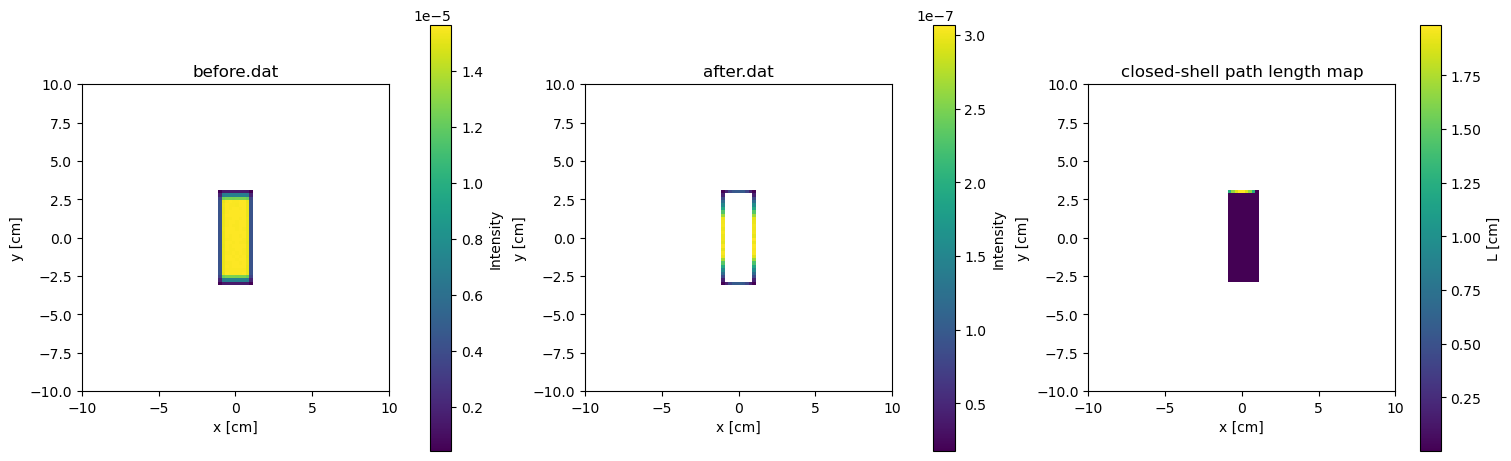

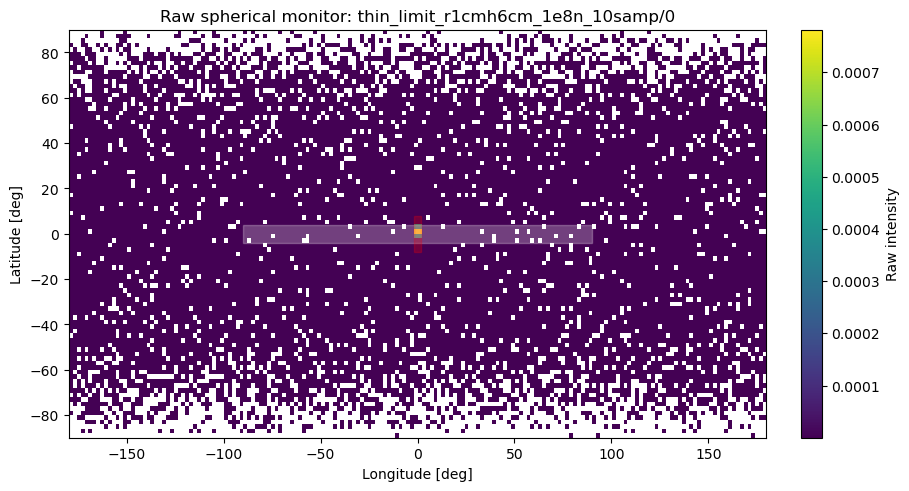


################################################################################
DIAGNOSING HIGHEST-RATIO RUN
################################################################################
Run: thin_limit_1e10n_22samp/0
Geometry
--------
R = 10 mm
H = 10 mm
t = 0.001 mm
Side-wall volume:    0.00062828711 cm^3
Closed-shell volume: 0.00125648 cm^3
Projected area:      2 cm^2

Before/after monitors
---------------------
before total:              0.00010670201
after total:               1.7032818e-06
before - after:            0.00010499873
(before - after) / before: 0.98403702
projected before sum:      9.5784368e-05

Projected beam distribution
---------------------------
beam fraction in middle/side region: 1
beam fraction in lid region:         0
linear expected side fraction:       1
linear expected lid fraction:        0

Path lengths and probabilities
------------------------------
L_geom side-wall only:     0.00031414356 cm
L_geom closed-shell:       0.00062823999 cm
L_flux no 

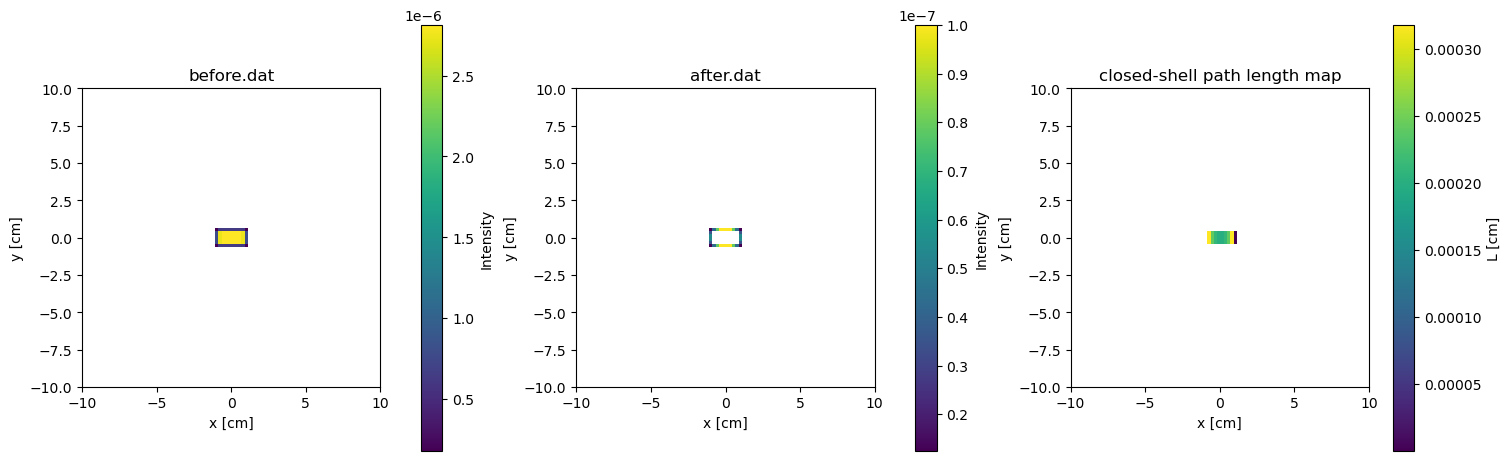

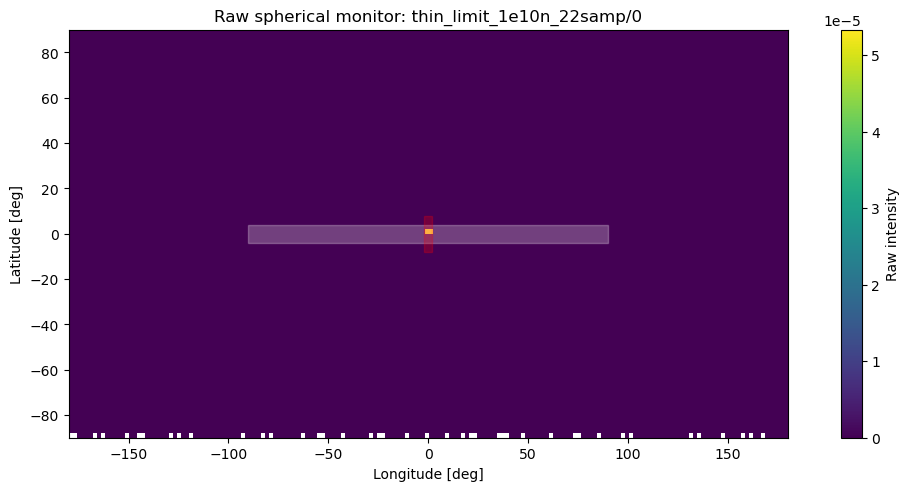

In [47]:
# ============================================================
# Diagnostic cell for suspicious self-absorption outliers
# ============================================================
# Paste this AFTER the main self-absorption cell.
#
# Purpose:
#   Diagnose why some thin-limit runs give ratios like 0.07 or 1.6.
#
# It compares:
#   - include_lids = True vs False
#   - raw observed intensity
#   - expected source strength
#   - lid/side-wall beam contributions
#   - detector window pixel count and solid angle
#   - monitor extents and bin sizes
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Helper: outer-cylinder chord
# ------------------------------------------------------------

def outer_cylinder_chord_cm(x_cm, geometry):
    R = geometry['outer_radius_mm'] / 10.0
    x = np.asarray(x_cm, dtype=float)
    ax = np.abs(x)

    L = np.zeros_like(ax, dtype=float)
    inside = ax <= R
    L[inside] = 2.0 * np.sqrt(np.maximum(R**2 - ax[inside]**2, 0.0))
    return L


# ------------------------------------------------------------
# Helper: decompose closed-shell path length into side/lid parts
# ------------------------------------------------------------

def path_length_components_cm(X_cm, Y_cm, geometry):
    """
    Decompose the closed-shell path length into approximate side-wall and lid parts.

    Beam direction is assumed along z.
    Cylinder axis is assumed vertical along y.

    side contribution:
        only for |y| <= H/2 - t, using annular side-wall chord

    lid contribution:
        only for H/2 - t < |y| <= H/2, using full outer-cylinder chord
    """
    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0
    t = geometry['wall_thickness_mm'] / 10.0

    X = np.asarray(X_cm, dtype=float)
    Y = np.asarray(Y_cm, dtype=float)

    ax = np.abs(X)
    ay = np.abs(Y)

    inner_half_height = H / 2.0 - t

    outer = (ax <= R) & (ay <= H / 2.0)
    middle_region = outer & (ay <= inner_half_height)
    lid_region = outer & (ay > inner_half_height)

    L_side = np.zeros_like(X, dtype=float)
    L_lid = np.zeros_like(X, dtype=float)

    # Side wall = annular chord.
    L_side[middle_region] = side_wall_chord_length_cm(X[middle_region], geometry)

    # Lids = full outer-cylinder chord.
    L_lid[lid_region] = outer_cylinder_chord_cm(X[lid_region], geometry)

    return L_side, L_lid, L_side + L_lid, middle_region, lid_region


# ------------------------------------------------------------
# Expected/observed calculation with explicit lid switch
# ------------------------------------------------------------

def expected_source_with_lid_switch(run_dir, lids):
    """
    Compute expected scattered source strength with include_lids explicitly
    controlled locally, without relying on global state.
    """
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    before_data, before_meta = load_mccode_2d(Path(run_dir) / 'before.dat')
    extent = before_meta.get('extent')

    if extent is None:
        raise ValueError(f'before.dat is missing xylimits/extent for {run_dir}')

    x_min, x_max, y_min, y_max = extent
    n_y, n_x = before_data.shape

    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0

    x_mask = (x_centers >= -R) & (x_centers <= R)
    y_mask = (y_centers >= -0.5 * H) & (y_centers <= 0.5 * H)

    I = np.asarray(before_data[np.ix_(y_mask, x_mask)], dtype=float)
    X, Y = np.meshgrid(x_centers[x_mask], y_centers[y_mask])

    if lids:
        L = shell_chord_length_cm(X, Y, geometry)
    else:
        L = side_wall_chord_length_cm(X, geometry)

    P = scattering_probability_from_path_length(L)

    return float(np.nansum(I * P))


def expected_window_with_lid_switch(run_dir, lids):
    _, omega = detector_window_observed_sum_and_solid_angle(run_dir)
    source = expected_source_with_lid_switch(run_dir, lids)
    return source * omega / (4.0 * np.pi)


def self_abs_with_lid_switch(run_dir, lids):
    observed, _ = detector_window_observed_sum_and_solid_angle(run_dir)
    expected = expected_window_with_lid_switch(run_dir, lids)
    return observed / expected if expected > 0 else np.nan


# ------------------------------------------------------------
# Detailed single-run diagnostic
# ------------------------------------------------------------

def diagnose_self_absorption_run(run_dir, show_plots=True):
    run_dir = Path(run_dir)
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    before_data, before_meta = load_mccode_2d(run_dir / 'before.dat')
    after_data, after_meta = load_mccode_2d(run_dir / 'after.dat')

    before_total = float(np.nansum(before_data))
    after_total = float(np.nansum(after_data))

    observed_sum, omega_window = detector_window_observed_sum_and_solid_angle(run_dir)

    expected_lids_on = expected_window_with_lid_switch(run_dir, lids=True)
    expected_lids_off = expected_window_with_lid_switch(run_dir, lids=False)

    ratio_lids_on = observed_sum / expected_lids_on if expected_lids_on > 0 else np.nan
    ratio_lids_off = observed_sum / expected_lids_off if expected_lids_off > 0 else np.nan

    # Projected sample pixels.
    I, X, Y, _ = projected_sample_pixels(run_dir)

    L_side, L_lid, L_total, middle_region, lid_region = path_length_components_cm(X, Y, geometry)

    P_side_linear = Sigma_inc_cm_inv * L_side
    P_lid_linear = Sigma_inc_cm_inv * L_lid
    P_total_linear = Sigma_inc_cm_inv * L_total

    # These are linearized contributions, only used diagnostically.
    side_linear_source = float(np.nansum(I * P_side_linear))
    lid_linear_source = float(np.nansum(I * P_lid_linear))
    total_linear_source = float(np.nansum(I * P_total_linear))

    projected_before_sum = float(np.nansum(I))

    lid_beam_sum = float(np.nansum(I[lid_region]))
    middle_beam_sum = float(np.nansum(I[middle_region]))

    lid_beam_fraction = lid_beam_sum / projected_before_sum if projected_before_sum > 0 else np.nan
    middle_beam_fraction = middle_beam_sum / projected_before_sum if projected_before_sum > 0 else np.nan

    lid_expected_fraction_linear = lid_linear_source / total_linear_source if total_linear_source > 0 else np.nan
    side_expected_fraction_linear = side_linear_source / total_linear_source if total_linear_source > 0 else np.nan

    # Spherical monitor details.
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hraw = np.array(sphere_mon.Intensity, copy=True)

    if hasattr(meta, 'dimension') and Hraw.shape == (meta.dimension[0], meta.dimension[1]):
        Hraw = Hraw.T

    xmin, xmax, ymin, ymax = meta.limits
    n_lat, n_lon = Hraw.shape

    lon_edges = np.linspace(xmin, xmax, n_lon + 1)
    lat_edges = np.linspace(ymin, ymax, n_lat + 1)
    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    Lon, Lat = np.meshgrid(lon_centers, lat_centers)

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        & (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    lon_mask = angular_window_mask(lon_centers, nominal_detector_center_deg, detector_window_width_deg)
    lat_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    window_mask = np.outer(lat_mask, lon_mask)

    valid_mask = (
        window_mask
        & ~beam_center_mask
        & np.isfinite(Hraw)
        & (Hraw > 0)
    )

    n_window_pixels = int(np.count_nonzero(window_mask))
    n_valid_pixels = int(np.count_nonzero(valid_mask))

    # Print report.
    print('=' * 80)
    print(f'Run: {run_dir.parent.name}/{run_dir.name}')
    print('=' * 80)
    print('Geometry')
    print('--------')
    print(f"R = {geometry['outer_radius_mm']:.8g} mm")
    print(f"H = {geometry['outer_height_mm']:.8g} mm")
    print(f"t = {geometry['wall_thickness_mm']:.8g} mm")
    print(f"Side-wall volume:    {side_wall_volume_cm3(run_dir):.8g} cm^3")
    print(f"Closed-shell volume: {closed_shell_volume_cm3(run_dir):.8g} cm^3")
    print(f"Projected area:      {projected_area_cm2(run_dir):.8g} cm^2")
    print()

    print('Before/after monitors')
    print('---------------------')
    print(f'before total:              {before_total:.8g}')
    print(f'after total:               {after_total:.8g}')
    print(f'before - after:            {before_total - after_total:.8g}')
    print(f'(before - after) / before: {(before_total - after_total) / before_total:.8g}')
    print(f'projected before sum:      {projected_before_sum:.8g}')
    print()

    print('Projected beam distribution')
    print('---------------------------')
    print(f'beam fraction in middle/side region: {middle_beam_fraction:.8g}')
    print(f'beam fraction in lid region:         {lid_beam_fraction:.8g}')
    print(f'linear expected side fraction:       {side_expected_fraction_linear:.8g}')
    print(f'linear expected lid fraction:        {lid_expected_fraction_linear:.8g}')
    print()

    print('Path lengths and probabilities')
    print('------------------------------')
    print(f'L_geom side-wall only:     {side_wall_volume_cm3(run_dir) / projected_area_cm2(run_dir):.8g} cm')
    print(f'L_geom closed-shell:       {closed_shell_volume_cm3(run_dir) / projected_area_cm2(run_dir):.8g} cm')

    old_include_lids = globals().get('include_lids', None)

    globals()['include_lids'] = False
    try:
        L_flux_no_lids = flux_weighted_mean_path_length_cm(run_dir)
        P_flux_no_lids = flux_weighted_scattering_probability(run_dir)
    finally:
        globals()['include_lids'] = old_include_lids

    globals()['include_lids'] = True
    try:
        L_flux_lids = flux_weighted_mean_path_length_cm(run_dir)
        P_flux_lids = flux_weighted_scattering_probability(run_dir)
    finally:
        globals()['include_lids'] = old_include_lids

    print(f'L_flux no lids:           {L_flux_no_lids:.8g} cm')
    print(f'L_flux with lids:         {L_flux_lids:.8g} cm')
    print(f'P_flux no lids:           {P_flux_no_lids:.8g}')
    print(f'P_flux with lids:         {P_flux_lids:.8g}')
    print()

    print('Detector window')
    print('---------------')
    print(f'spherical monitor shape:      {Hraw.shape}')
    print(f'lon range:                    {xmin:.8g} to {xmax:.8g} deg')
    print(f'lat range:                    {ymin:.8g} to {ymax:.8g} deg')
    print(f'window pixels before masks:   {n_window_pixels}')
    print(f'valid positive window pixels: {n_valid_pixels}')
    print(f'omega window:                 {omega_window:.8g} sr')
    print(f'omega / 4pi:                  {omega_window / (4.0 * np.pi):.8g}')
    print()

    print('Expected vs observed')
    print('--------------------')
    print(f'observed window sum:       {observed_sum:.8g}')
    print(f'expected window, no lids:  {expected_lids_off:.8g}')
    print(f'expected window, lids:     {expected_lids_on:.8g}')
    print(f'obs/exp no lids:           {ratio_lids_off:.8g}')
    print(f'obs/exp lids:              {ratio_lids_on:.8g}')
    print()

    if show_plots:
        extent = before_meta.get('extent', [-1, 1, -1, 1])

        fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

        im0 = axs[0].imshow(
            np.ma.masked_less_equal(before_data, 0),
            extent=extent,
            origin='lower',
            aspect='equal',
        )
        axs[0].set_title('before.dat')
        axs[0].set_xlabel('x [cm]')
        axs[0].set_ylabel('y [cm]')
        fig.colorbar(im0, ax=axs[0], label='Intensity')

        im1 = axs[1].imshow(
            np.ma.masked_less_equal(after_data, 0),
            extent=extent,
            origin='lower',
            aspect='equal',
        )
        axs[1].set_title('after.dat')
        axs[1].set_xlabel('x [cm]')
        axs[1].set_ylabel('y [cm]')
        fig.colorbar(im1, ax=axs[1], label='Intensity')

        # Path length map over projected sample pixels.
        Lplot = np.full_like(before_data, np.nan, dtype=float)

        x_min_b, x_max_b, y_min_b, y_max_b = extent
        ny_b, nx_b = before_data.shape
        x_edges_b = np.linspace(x_min_b, x_max_b, nx_b + 1)
        y_edges_b = np.linspace(y_min_b, y_max_b, ny_b + 1)
        x_centers_b = 0.5 * (x_edges_b[:-1] + x_edges_b[1:])
        y_centers_b = 0.5 * (y_edges_b[:-1] + y_edges_b[1:])
        Xb, Yb = np.meshgrid(x_centers_b, y_centers_b)

        Lplot[:, :] = shell_chord_length_cm(Xb, Yb, geometry)

        im2 = axs[2].imshow(
            np.ma.masked_less_equal(Lplot, 0),
            extent=extent,
            origin='lower',
            aspect='equal',
        )
        axs[2].set_title('closed-shell path length map')
        axs[2].set_xlabel('x [cm]')
        axs[2].set_ylabel('y [cm]')
        fig.colorbar(im2, ax=axs[2], label='L [cm]')

        plt.show()

        # Spherical monitor raw detector window.
        fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
        im = ax.imshow(
            np.ma.masked_less_equal(Hraw, 0),
            extent=[xmin, xmax, ymin, ymax],
            origin='lower',
            aspect='auto',
        )
        ax.axvspan(
            nominal_detector_center_deg - detector_window_width_deg / 2.0,
            nominal_detector_center_deg + detector_window_width_deg / 2.0,
            ymin=0.5 - equator_band_halfwidth_local / 90.0,
            ymax=0.5 + equator_band_halfwidth_local / 90.0,
            color='white',
            alpha=0.25,
        )
        ax.axvspan(
            -beam_lon_halfwidth_deg_local,
            beam_lon_halfwidth_deg_local,
            ymin=0.5 - beam_lat_halfwidth_deg_local / 90.0,
            ymax=0.5 + beam_lat_halfwidth_deg_local / 90.0,
            color='red',
            alpha=0.25,
        )
        ax.set_title(f'Raw spherical monitor: {run_dir.parent.name}/{run_dir.name}')
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Latitude [deg]')
        fig.colorbar(im, ax=ax, label='Raw intensity')
        plt.show()


# ------------------------------------------------------------
# Choose suspicious runs automatically
# ------------------------------------------------------------

if 'self_absorption_rows' not in globals():
    raise RuntimeError(
        'Run the main self-absorption cell first, so self_absorption_rows exists.'
    )

valid_rows = [
    row for row in self_absorption_rows
    if np.isfinite(row['self_absorption'])
]

sorted_rows = sorted(valid_rows, key=lambda row: row['self_absorption'])

lowest_rows = sorted_rows[:5]
highest_rows = list(reversed(sorted_rows))[:5]

print('Lowest-ratio runs:')
for row in lowest_rows:
    print(
        f"  {row['self_absorption']:.6g}  "
        f"{row['scan']}/{row['run']}  "
        f"r={row['radius_mm']:.4g} mm, "
        f"h={row['height_mm']:.4g} mm, "
        f"t={row['thickness_mm']:.6g} mm"
    )

print()
print('Highest-ratio runs:')
for row in highest_rows:
    print(
        f"  {row['self_absorption']:.6g}  "
        f"{row['scan']}/{row['run']}  "
        f"r={row['radius_mm']:.4g} mm, "
        f"h={row['height_mm']:.4g} mm, "
        f"t={row['thickness_mm']:.6g} mm"
    )

# ------------------------------------------------------------
# Diagnose the worst low-ratio run and worst high-ratio run
# ------------------------------------------------------------

print()
print('#' * 80)
print('DIAGNOSING LOWEST-RATIO RUN')
print('#' * 80)
diagnose_self_absorption_run(lowest_rows[0]['run_dir'], show_plots=True)

print()
print('#' * 80)
print('DIAGNOSING HIGHEST-RATIO RUN')
print('#' * 80)
diagnose_self_absorption_run(highest_rows[0]['run_dir'], show_plots=True)

# ------------------------------------------------------------
# Optional: diagnose a specific run manually
# ------------------------------------------------------------
# Uncomment and edit this if needed:
#
# diagnose_self_absorption_run(
#     flatness_root / 'thin_limit_r1cmh6cm_1e8n_10samp' / '0',
#     show_plots=True
# )

Computed model comparison for 468 runs.

Thin-limit rows with t <= 0.05 mm: 26

Thin-limit ratio statistics by model
------------------------------------
geom_side     median=0.843896, mean=0.912263, std=0.116169, median(|ratio-1|)=0.167198, min=0.799224, max=1.15754
geom_closed   median=0.648726, mean=0.613343, std=0.0818248, median(|ratio-1|)=0.351274, min=0.503067, max=0.74116
flux_side     median=1.16946, mean=1.26125, std=0.161047, median(|ratio-1|)=0.169459, min=1.10611, max=1.60408
flux_closed   median=1.13024, mean=1.15267, std=0.3437, median(|ratio-1|)=0.352301, min=0.0728759, max=1.60408

Best thin-limit model by median absolute deviation from 1: geom_side

Worst thin-limit deviations by model
------------------------------------

Model: geom_side
  ratio=0.799224  thin_limit_r1cmh6cm_1e8n_10samp/1  r=10 mm, h=60 mm, t=0.012 mm
  ratio=0.799458  thin_limit_r1cmh4cm_1e8n_10samp/1  r=10 mm, h=40 mm, t=0.012 mm
  ratio=0.800958  thin_limit_r1cmh5cm_1e8n_10samp/3  r=10 mm, h=50 m

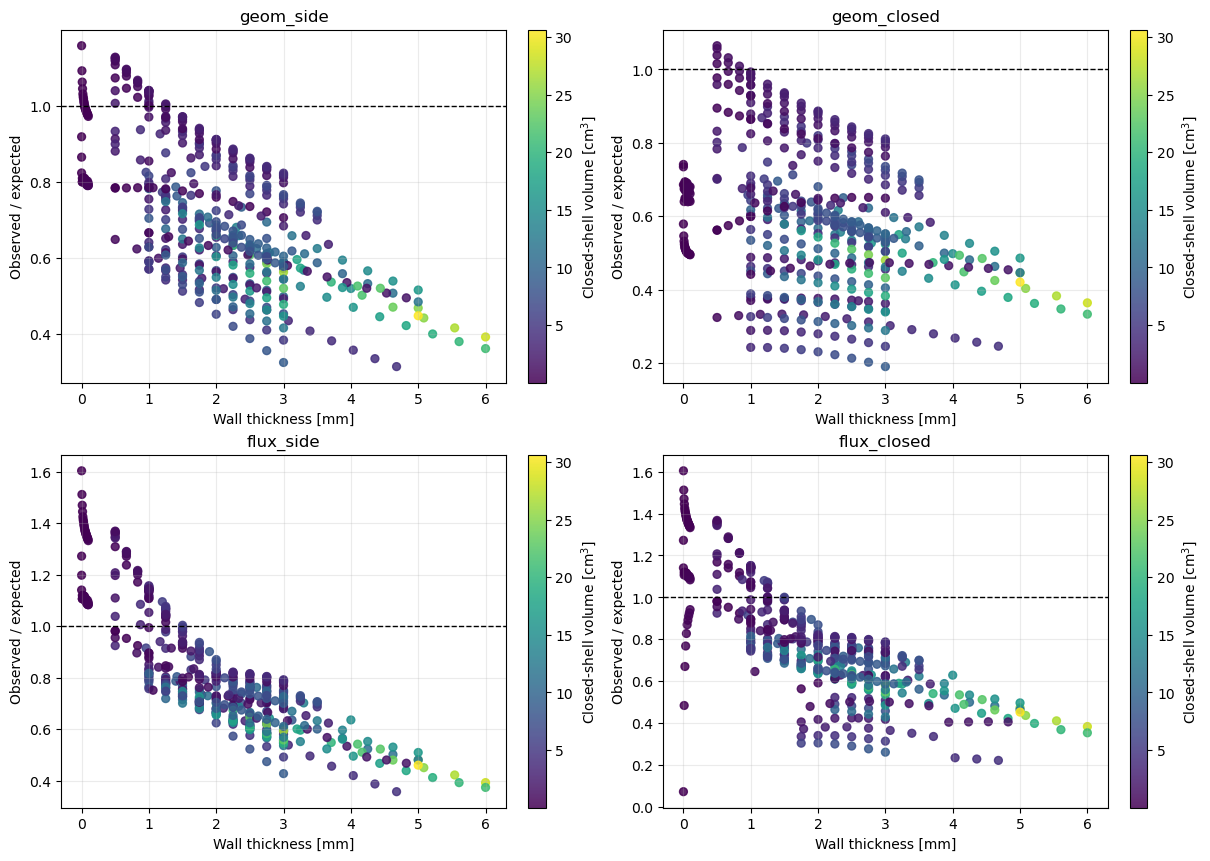

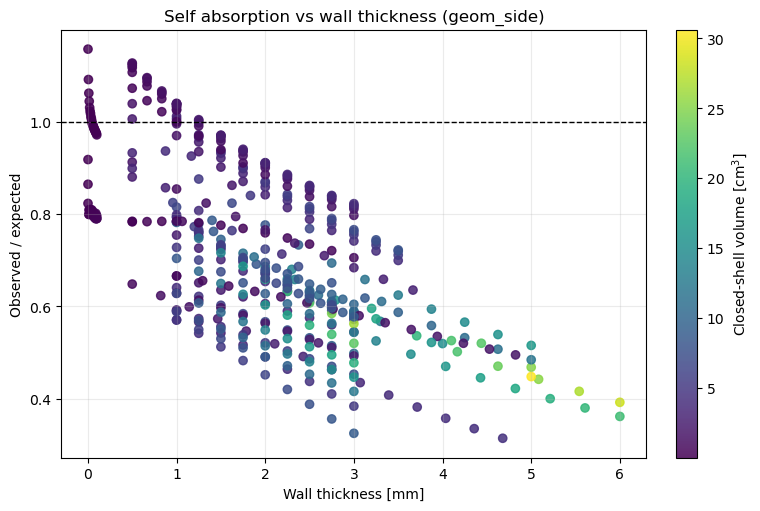


Problem-scan model comparison
-----------------------------

Scan: thin_limit_r1cmh6cm_1e8n_10samp
  run=0    t=0.001 mm  geom_side=0.8647  geom_closed=0.7412  flux_side=1.198  flux_closed=0.07288
  run=1    t=0.012 mm  geom_side=0.7992  geom_closed=0.6854  flux_side=1.106  flux_closed=0.4842
  run=2    t=0.023 mm  geom_side=0.8088  geom_closed=0.6939  flux_side=1.118  flux_closed=0.6702
  run=3    t=0.034 mm  geom_side=0.8067  geom_closed=0.6924  flux_side=1.114  flux_closed=0.7679
  run=4    t=0.045 mm  geom_side=0.8039  geom_closed=0.6903  flux_side=1.109  flux_closed=0.8276
  run=5    t=0.056 mm  geom_side=0.803  geom_closed=0.6898  flux_side=1.106  flux_closed=0.8695
  run=6    t=0.067 mm  geom_side=0.7943  geom_closed=0.6827  flux_side=1.093  flux_closed=0.8909
  run=7    t=0.078 mm  geom_side=0.7918  geom_closed=0.6808  flux_side=1.088  flux_closed=0.9108
  run=8    t=0.089 mm  geom_side=0.7898  geom_closed=0.6794  flux_side=1.084  flux_closed=0.9263
  run=9    t=0.1 mm  geom_s

In [48]:
# ============================================================
# Model-comparison diagnostic for self-absorption normalization
# ============================================================
# Paste this AFTER the main self-absorption cell.
#
# This compares several Born/expected-intensity models:
#
#   1. geom_side:
#        projected_before_sum * P(V_side / A_proj)
#
#   2. geom_closed:
#        projected_before_sum * P(V_closed / A_proj)
#
#   3. flux_side:
#        sum_pixels I_before(x,y) * P(L_side(x))
#
#   4. flux_closed:
#        sum_pixels I_before(x,y) * P(L_closed(x,y))
#
# The goal is to identify which normalization/model behaves correctly
# in the thin limit.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Settings for this diagnostic
# ------------------------------------------------------------

thin_limit_max_thickness_mm = 0.05
make_diagnostic_plots = True

model_names = [
    'geom_side',
    'geom_closed',
    'flux_side',
    'flux_closed',
]

# ------------------------------------------------------------
# Robust helpers
# ------------------------------------------------------------

def projected_pixel_grid(run_dir):
    """
    Return projected before intensity and pixel coordinates over the
    nominal projected cylinder rectangle.
    """
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    before_data, before_meta = load_mccode_2d(Path(run_dir) / 'before.dat')
    extent = before_meta.get('extent')

    if extent is None:
        raise ValueError(f'before.dat is missing xylimits/extent for {run_dir}')

    x_min, x_max, y_min, y_max = extent
    n_y, n_x = before_data.shape

    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0

    x_mask = (x_centers >= -R) & (x_centers <= R)
    y_mask = (y_centers >= -0.5 * H) & (y_centers <= 0.5 * H)

    I = np.asarray(before_data[np.ix_(y_mask, x_mask)], dtype=float)
    X, Y = np.meshgrid(x_centers[x_mask], y_centers[y_mask])

    return I, X, Y, geometry


def expected_source_for_model(run_dir, model):
    """
    Expected total single-scattered source strength for a chosen model.
    """
    I, X, Y, geometry = projected_pixel_grid(run_dir)
    projected_before_sum = float(np.nansum(I))

    if projected_before_sum <= 0:
        return np.nan

    R = geometry['outer_radius_mm'] / 10.0
    H = geometry['outer_height_mm'] / 10.0

    A_proj = 2.0 * R * H

    # Side-wall geometric mean.
    V_side = side_wall_volume_cm3(run_dir)
    L_geom_side = V_side / A_proj

    # Closed-shell geometric mean.
    V_closed = closed_shell_volume_cm3(run_dir)
    L_geom_closed = V_closed / A_proj

    if model == 'geom_side':
        P = scattering_probability_from_path_length(L_geom_side)
        return float(projected_before_sum * P)

    if model == 'geom_closed':
        P = scattering_probability_from_path_length(L_geom_closed)
        return float(projected_before_sum * P)

    if model == 'flux_side':
        L = side_wall_chord_length_cm(X, geometry)
        P = scattering_probability_from_path_length(L)
        return float(np.nansum(I * P))

    if model == 'flux_closed':
        L = shell_chord_length_cm(X, Y, geometry)
        P = scattering_probability_from_path_length(L)
        return float(np.nansum(I * P))

    raise ValueError(f'Unknown model: {model}')


def expected_window_for_model(run_dir, model):
    observed_sum, omega = detector_window_observed_sum_and_solid_angle(run_dir)
    source = expected_source_for_model(run_dir, model)
    expected = source * omega / (4.0 * np.pi)
    return expected


def ratio_for_model(run_dir, model):
    observed_sum, omega = detector_window_observed_sum_and_solid_angle(run_dir)
    expected = expected_window_for_model(run_dir, model)

    if expected <= 0 or not np.isfinite(expected):
        return np.nan

    return observed_sum / expected


def run_model_comparison_row(run_dir):
    run_dir = Path(run_dir)
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))

    observed_sum, omega = detector_window_observed_sum_and_solid_angle(run_dir)

    I, X, Y, _ = projected_pixel_grid(run_dir)
    projected_before_sum = float(np.nansum(I))

    row = {
        'run_dir': run_dir,
        'scan': run_dir.parent.name,
        'run': run_dir.name,
        'radius_mm': geometry['outer_radius_mm'],
        'height_mm': geometry['outer_height_mm'],
        'thickness_mm': geometry['wall_thickness_mm'],
        'side_wall_volume_cm3': side_wall_volume_cm3(run_dir),
        'closed_shell_volume_cm3': closed_shell_volume_cm3(run_dir),
        'projected_before_sum': projected_before_sum,
        'observed_sum': observed_sum,
        'omega_window_sr': omega,
    }

    for model in model_names:
        expected_source = expected_source_for_model(run_dir, model)
        expected_window = expected_source * omega / (4.0 * np.pi)

        row[f'{model}_expected_source'] = expected_source
        row[f'{model}_expected_window'] = expected_window
        row[f'{model}_ratio'] = (
            observed_sum / expected_window
            if expected_window > 0 and np.isfinite(expected_window)
            else np.nan
        )

    return row


def compute_model_comparison_rows(run_dirs):
    rows = []
    failed = []

    for run_dir in run_dirs:
        try:
            rows.append(run_model_comparison_row(run_dir))
        except Exception as exc:
            failed.append((Path(run_dir), exc))

    return rows, failed


# ------------------------------------------------------------
# Compute model comparison
# ------------------------------------------------------------

comparison_rows, comparison_failed = compute_model_comparison_rows(flatness_run_dirs)

comparison_rows = [
    row for row in comparison_rows
    if all(np.isfinite(row.get(f'{model}_ratio', np.nan)) for model in model_names)
]

if not comparison_rows:
    raise ValueError('No finite model-comparison rows computed.')

print(f'Computed model comparison for {len(comparison_rows)} runs.')
if comparison_failed:
    print(f'Failed comparison for {len(comparison_failed)} runs.')

# ------------------------------------------------------------
# Thin-limit statistics
# ------------------------------------------------------------

thin_rows = [
    row for row in comparison_rows
    if row['thickness_mm'] <= thin_limit_max_thickness_mm
]

print()
print(f'Thin-limit rows with t <= {thin_limit_max_thickness_mm:g} mm: {len(thin_rows)}')

if not thin_rows:
    raise ValueError('No thin-limit rows found for diagnostic.')

print()
print('Thin-limit ratio statistics by model')
print('------------------------------------')

model_scores = {}

for model in model_names:
    values = np.array([row[f'{model}_ratio'] for row in thin_rows], dtype=float)
    values = values[np.isfinite(values)]

    median = np.median(values)
    mean = np.mean(values)
    std = np.std(values)
    mad_from_1 = np.median(np.abs(values - 1.0))

    model_scores[model] = mad_from_1

    print(
        f'{model:<12}  '
        f'median={median:.6g}, '
        f'mean={mean:.6g}, '
        f'std={std:.6g}, '
        f'median(|ratio-1|)={mad_from_1:.6g}, '
        f'min={np.min(values):.6g}, '
        f'max={np.max(values):.6g}'
    )

best_model = min(model_scores, key=model_scores.get)

print()
print(f'Best thin-limit model by median absolute deviation from 1: {best_model}')

# ------------------------------------------------------------
# Print worst thin-limit rows for each model
# ------------------------------------------------------------

print()
print('Worst thin-limit deviations by model')
print('------------------------------------')

for model in model_names:
    sorted_thin = sorted(
        thin_rows,
        key=lambda row: abs(row[f'{model}_ratio'] - 1.0),
        reverse=True,
    )

    print()
    print(f'Model: {model}')
    for row in sorted_thin[:8]:
        print(
            f"  ratio={row[f'{model}_ratio']:.6g}  "
            f"{row['scan']}/{row['run']}  "
            f"r={row['radius_mm']:.4g} mm, "
            f"h={row['height_mm']:.4g} mm, "
            f"t={row['thickness_mm']:.6g} mm"
        )

# ------------------------------------------------------------
# Scan-level thin-limit summary
# ------------------------------------------------------------

print()
print('Thin-limit scan-level medians')
print('-----------------------------')

scan_names = sorted({row['scan'] for row in thin_rows})

for scan in scan_names:
    scan_rows = [row for row in thin_rows if row['scan'] == scan]

    print()
    print(f'Scan: {scan}   n={len(scan_rows)}')

    for model in model_names:
        values = np.array([row[f'{model}_ratio'] for row in scan_rows], dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        print(
            f'  {model:<12} '
            f'median={np.median(values):.6g}, '
            f'min={np.min(values):.6g}, '
            f'max={np.max(values):.6g}'
        )

# ------------------------------------------------------------
# Choose one robust ratio for plotting
# ------------------------------------------------------------
# For now we use the best global thin-limit model.
# You can change chosen_model manually after looking at the printout.
# ------------------------------------------------------------

chosen_model = best_model

print()
print(f'Using chosen_model = {chosen_model!r} for the diagnostic plots below.')

thickness_values = np.array([row['thickness_mm'] for row in comparison_rows])
volume_values = np.array([row['closed_shell_volume_cm3'] for row in comparison_rows])
chosen_ratios = np.array([row[f'{chosen_model}_ratio'] for row in comparison_rows])

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------

if make_diagnostic_plots:
    fig, axs = plt.subplots(2, 2, figsize=(12, 8.5), constrained_layout=True)
    axs = axs.ravel()

    for ax, model in zip(axs, model_names):
        values = np.array([row[f'{model}_ratio'] for row in comparison_rows], dtype=float)

        scatter = ax.scatter(
            thickness_values,
            values,
            c=volume_values,
            cmap='viridis',
            s=32,
            alpha=0.85,
        )

        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0)
        ax.set_title(model)
        ax.set_xlabel('Wall thickness [mm]')
        ax.set_ylabel('Observed / expected')
        ax.grid(alpha=0.25)

        fig.colorbar(scatter, ax=ax, label='Closed-shell volume [cm$^3$]')

    plt.show()

    fig, ax = plt.subplots(figsize=(7.5, 5.0), constrained_layout=True)

    scatter = ax.scatter(
        thickness_values,
        chosen_ratios,
        c=volume_values,
        cmap='viridis',
        s=36,
        alpha=0.85,
    )

    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0)
    ax.set_title(f'Self absorption vs wall thickness ({chosen_model})')
    ax.set_xlabel('Wall thickness [mm]')
    ax.set_ylabel('Observed / expected')
    ax.grid(alpha=0.25)
    fig.colorbar(scatter, ax=ax, label='Closed-shell volume [cm$^3$]')

    plt.show()

# ------------------------------------------------------------
# Detailed check of the two problematic thin-limit scans
# ------------------------------------------------------------

problem_scans = [
    'thin_limit_r1cmh6cm_1e8n_10samp',
    'thin_limit_1e10n_22samp',
]

print()
print('Problem-scan model comparison')
print('-----------------------------')

for scan in problem_scans:
    rows = [row for row in comparison_rows if row['scan'] == scan]

    if not rows:
        print(f'No rows found for scan: {scan}')
        continue

    rows = sorted(rows, key=lambda row: row['thickness_mm'])

    print()
    print(f'Scan: {scan}')

    for row in rows[:10]:
        pieces = [
            f"{model}={row[f'{model}_ratio']:.4g}"
            for model in model_names
        ]

        print(
            f"  run={row['run']:<4} "
            f"t={row['thickness_mm']:.6g} mm  "
            + "  ".join(pieces)
        )

# ------------------------------------------------------------
# Suggested interpretation
# ------------------------------------------------------------

print()
print('Interpretation guide')
print('--------------------')
print(
    'If geom_side is closest to 1 in the thin limit, the old V/A side-wall '
    'estimate is the best normalization for these simulations.'
)
print(
    'If flux_side is closest to 1, the beam profile correction matters, but '
    'the sample should be treated as open/no lids.'
)
print(
    'If flux_closed or geom_closed creates extreme low ratios for very thin '
    'samples, the lid model is not consistent with that scan.'
)
print(
    'Any thin-limit scan that cannot get near 1 under any model likely has a '
    'different monitor setup, geometry setup, or normalization convention.'
)

In [ ]:
lon_deg, observed_cut, observed_cut_err, valid_cols = get_equator_cut_from_run(fhit_dir)
expected_born = expected_intensity(fhit_dir)

two_theta_deg = (lon_deg + 360.0) % 360.0
sort_idx = np.argsort(two_theta_deg)

two_theta_sorted = two_theta_deg[sort_idx]
observed_sorted = observed_cut[sort_idx]
observed_err_sorted = observed_cut_err[sort_idx]
valid_sorted = valid_cols[sort_idx] & np.isfinite(observed_sorted) & (observed_sorted > 0)
ratio_sorted = np.full_like(observed_sorted, np.nan, dtype=float)
ratio_sorted[valid_sorted] = observed_sorted[valid_sorted] / expected_born

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

axs[0].plot(
    two_theta_sorted[valid_sorted],
    observed_sorted[valid_sorted],
    color='tab:blue',
    lw=1.4,
    label='Observed',
)
axs[0].fill_between(
    two_theta_sorted[valid_sorted],
    observed_sorted[valid_sorted] - observed_err_sorted[valid_sorted],
    observed_sorted[valid_sorted] + observed_err_sorted[valid_sorted],
    color='tab:blue',
    alpha=0.18,
    linewidth=0,
)
axs[0].axhline(
    expected_born,
    color='tab:red',
    lw=1.4,
    linestyle='--',
    label='Expected Born approximation',
)
axs[0].set_title(f'{fhit_dir.parent.name}/{fhit_dir.name}: observed vs expected in 2theta')
axs[0].set_ylabel('Intensity')
axs[0].legend()

axs[1].plot(
    two_theta_sorted[valid_sorted],
    ratio_sorted[valid_sorted],
    color='tab:green',
    lw=1.4,
)
axs[1].set_xlabel('2phi[deg]')
axs[1].set_ylabel('Observed / expected')
axs[1].set_xlim(0, 360)

plt.show()
